# Sun-aligned shadow sweep: a pure-Python shadow mask prototype

Prototype of `docs/proposed-tasks/sun-aligned-shadow-sweep.md`'s design: build a Cartesian frame
where the Sun sits at infinity along `+x`, project the DEM into it, and turn per-pixel horizon
occlusion into a single running-max sweep per row -- no per-pixel ray/DEM intersection search, the
approach ISIS `shadow` and ASP's `isInShadow` both use.

Uses the same candidate and DEM as `isis_shadow_spike.py`/`asp_sfs_shadow_spike.py`
(`M1327218454CE`, the lowest sun-elevation candidate in the manifest), and reuses
`geo_utils.local_orthographic_crs`/`moon_geocentric_crs` -- the same real body-fixed Cartesian
transform `hapke._terrain_photometric_angles` already uses and has validated against ISIS `campt`
and ASP `sfs` -- rather than a flat local-tangent-plane approximation (checked: the Moon's own
curvature over half this DEM's width is ~4.2km, comparable to this candidate's ~8.3km elevation
range, not a negligible correction).

Disposable, kept for reference rather than deleted -- not imported by anything, same spirit as the
other spike notebooks in this investigation.

In [1]:
import numpy as np
import rasterio
import rasterio.warp
import spiceypy as spice
from matplotlib import pyplot as plt
from matplotlib.colors import LightSource
from rasterio.warp import transform as warp_transform
from scipy import ndimage
from scipy.stats import binned_statistic_2d

import trntest
from trntest import dem_ortho, hapke, illumination, isis_wac
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import local_orthographic_crs, moon_geocentric_crs

CANDIDATE_PRODUCT_ID = "M1327218454CE"
UPSAMPLE_FACTOR = 2  # DEM resolution multiplier before projecting into the sun-aligned frame
BIN_SIZE_SAFETY_FACTOR = 2.0  # sun-aligned bin size, as a multiple of the upsampled grid's spacing
SELF_SHADOW_INCIDENCE_DEG = 90.0  # facing away from the Sun at or beyond this incidence angle
CONFIDENT_LIT_THRESHOLD = 0.9  # illumination_fraction above this: confidently lit, for the WAC check
CONFIDENT_SHADOW_THRESHOLD = 0.1  # illumination_fraction below this: confidently shadowed

## Candidate and DEM

Same plain `dem_ortho.fetch_dem` call as `isis_shadow_spike.py` -- no ortho/camera/image needed at
all for this method, unlike every ASP `sfs`-based attempt.

In [2]:
session = trntest.Session()
config = session.config

images = trntest.read_manifest("dataset_manifest.csv")
dataset = trntest.TrnTestDataSet.create(config.output_dir / "trn_dataset", images, config)
entry = dataset[CANDIDATE_PRODUCT_ID]
camera = entry.camera
center_lon_deg, center_lat_deg = camera.footprint_lonlat_deg["center"]
print(f"candidate: {entry.edr_product}, footprint center (lon,lat): ({center_lon_deg}, {center_lat_deg})")

dem_result = dem_ortho.fetch_dem(camera, entry.config)
with rasterio.open(dem_result.dem) as src:
    dem = src.read(1).astype(np.float64)
    cellsize_m = src.res[0]
height, width = dem.shape
minx, miny, maxx, maxy = dem_result.bbox
print(f"DEM: {dem_result.dem}, {width}x{height}, {cellsize_m:.3f} m/px")

candidate: M1327218454CE, footprint center (lon,lat): (177.77785856883, 73.514130051066)
ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


DEM: /workspace/output/dem_filled-tile-0.tif, 2424x2437, 100.000 m/px


## The sun-aligned frame

`x_hat`: the real Sun direction at this candidate's acquisition time, straight from SPICE (the same
`spice.spkpos` call `illumination.sun_azimuth_elevation_deg` uses internally, just kept as a raw
vector instead of converted to azimuth/elevation). `up_hat`: the local "anti-gravity" (radially
outward) direction at the DEM's own tangent point -- standard East-North-Up-frame math, the same
formula `hapke._terrain_photometric_angles` uses for its surface-normal computation.
Gram-Schmidt `up_hat` against `x_hat` to get `z_hat`; `y_hat` completes a right-handed frame
(confirmed: `y_hat = cross(z_hat, x_hat)` gives `cross(x_hat, y_hat) == z_hat`).

In [3]:
sun_dir_raw, _ = spice.spkpos("SUN", camera.et, "MOON_ME", "NONE", "MOON")
x_hat = np.array(sun_dir_raw) / np.linalg.norm(sun_dir_raw)

lon_rad, lat_rad = np.radians(center_lon_deg), np.radians(center_lat_deg)
up_hat = np.array([np.cos(lat_rad) * np.cos(lon_rad), np.cos(lat_rad) * np.sin(lon_rad), np.sin(lat_rad)])

z_hat = up_hat - np.dot(up_hat, x_hat) * x_hat
z_hat /= np.linalg.norm(z_hat)
y_hat = np.cross(z_hat, x_hat)

print(f"x_hat (sun dir):  {x_hat}")
print(f"y_hat:            {y_hat}")
print(f"z_hat (local up): {z_hat}")
print(
    f"orthonormality check: |x|={np.linalg.norm(x_hat):.6f} |y|={np.linalg.norm(y_hat):.6f} "
    f"|z|={np.linalg.norm(z_hat):.6f}, x.y={np.dot(x_hat, y_hat):.2e}, x.z={np.dot(x_hat, z_hat):.2e}, "
    f"y.z={np.dot(y_hat, z_hat):.2e}"
)
print(f"right-handedness check: cross(x,y) - z = {np.cross(x_hat, y_hat) - z_hat}")

x_hat (sun dir):  [-0.70464259  0.7091677   0.02366399]
y_hat:            [-0.69853109 -0.68744406 -0.19868311]
z_hat (local up): [-0.12463198 -0.15653061  0.97977806]
orthonormality check: |x|=1.000000 |y|=1.000000 |z|=1.000000, x.y=-6.53e-17, x.z=-1.16e-17, y.z=-2.65e-18
right-handedness check: cross(x,y) - z = [-2.77555756e-17  0.00000000e+00  0.00000000e+00]


## Real 3D positions: upsample, then project

Upsample the elevation raster in its own grid first (cubic spline) -- this is where the requested
antialiasing resolution comes from. Coordinates for the finer grid are recomputed analytically (a
regular grid needs no interpolation for its own coordinates, only the elevation values do). Ground
positions come from the same `local_orthographic_crs` -> `moon_geocentric_crs` transform
`hapke._terrain_photometric_angles` already uses, not a flat-plane approximation.

In [4]:
dem_fine = ndimage.zoom(dem, UPSAMPLE_FACTOR, order=3)
height_fine, width_fine = dem_fine.shape
cellsize_fine_m = cellsize_m / UPSAMPLE_FACTOR
print(f"upsampled DEM: {width_fine}x{height_fine}, {cellsize_fine_m:.3f} m/px")

x_centers = minx + (np.arange(width_fine) + 0.5) * (maxx - minx) / width_fine
y_centers = maxy - (np.arange(height_fine) + 0.5) * (maxy - miny) / height_fine  # row 0 = north/top
x_grid, y_grid = np.meshgrid(x_centers, y_centers)

ground_x, ground_y, ground_z = warp_transform(
    local_orthographic_crs(center_lon_deg, center_lat_deg, MOON_RADIUS_M),
    moon_geocentric_crs(MOON_RADIUS_M),
    x_grid.ravel(),
    y_grid.ravel(),
    dem_fine.ravel(),
)
ground = np.stack([ground_x, ground_y, ground_z], axis=-1)

(origin_x,), (origin_y,), (origin_z,) = warp_transform(
    local_orthographic_crs(center_lon_deg, center_lat_deg, MOON_RADIUS_M),
    moon_geocentric_crs(MOON_RADIUS_M),
    [0.0],
    [0.0],
    [0.0],
)
origin = np.array([origin_x, origin_y, origin_z])

rel = ground - origin
X = rel @ x_hat
Y = rel @ y_hat
Z = rel @ z_hat
print(f"X range: {X.min():.1f} .. {X.max():.1f} m")
print(f"Y range: {Y.min():.1f} .. {Y.max():.1f} m")
print(f"Z range: {Z.min():.1f} .. {Z.max():.1f} m")

upsampled DEM: 4848x4874, 50.000 m/px


X range: -175807.0 .. 158675.3 m
Y range: -172106.7 .. 171676.2 m
Z range: -46137.6 .. 32511.0 m


## Bin into the sun-aligned raster

Bin size is `BIN_SIZE_SAFETY_FACTOR` times the upsampled grid's own spacing, *not* 1x. At 1x, a
rotated square lattice binned onto an axis-aligned grid at matching spacing produces a textbook
lattice-aliasing (Moiré) pattern: most bins land almost exactly one source point each (measured:
77.7% of occupied bins held exactly 1 point at 1x), so the "max" statistic per bin is really just
"whichever single point happened to land there" -- no real aggregation, and the resulting
illumination map showed an obvious periodic checkerboard in bin occupancy, and a corresponding
"screen door" grid pattern in the antialiased output wherever that translated to partial
illumination. `BIN_SIZE_SAFETY_FACTOR=2.0` raises the mean points-per-occupied-bin from 1.22 to
4.10 and the count==1 fraction from 77.7% to ~0% -- confirmed to remove the screen-door pattern
directly (checked visually on the same crop), not just soften it the way a post-hoc blur would.
This also *shrinks* the raster (fewer, larger bins) rather than growing it, so it's cheaper, not
more expensive, unlike raising `UPSAMPLE_FACTOR` further (which doesn't fix this at all: the
aliasing ratio is scale-invariant when bin size is tied 1:1 to source spacing, confirmed by
identical occupancy statistics at `UPSAMPLE_FACTOR=2` and `4` before this fix).

Gaps with no source point are still expected and fine -- real nodata, not a false shadow signal.
This DEM's roughly-square footprint, once rotated to align with the sun direction, becomes a
diamond inscribed in a *larger* axis-aligned bounding box; the empty cells are the box's own
corners, genuinely outside the DEM (confirmed with `scipy.ndimage.distance_transform_edt`: empty
cells sit up to ~1200 bins from the nearest real sample, and the ~0.42-0.50 coverage fraction
matches the closed-form `1 / (|cos θ| + |sin θ|)²` area ratio for a rotated square, exactly 0.5 at
45°) -- a genuine footprint-shape effect, separate from the occupancy-aliasing issue above, and
still not worth gap-filling.

In [5]:
bin_size_m = cellsize_fine_m * BIN_SIZE_SAFETY_FACTOR
nx = int(np.ceil((X.max() - X.min()) / bin_size_m)) + 1
ny = int(np.ceil((Y.max() - Y.min()) / bin_size_m)) + 1
print(f"sun-aligned raster: {nx} (x, sun direction) x {ny} (y, cross-track), bin size {bin_size_m:.1f} m")

statistic, x_edges, y_edges, binnumber = binned_statistic_2d(
    X, Y, Z, statistic="max", bins=[nx, ny], expand_binnumbers=True
)
count, *_ = binned_statistic_2d(X, Y, np.ones_like(X), statistic="count", bins=[nx, ny])
coverage = np.isfinite(statistic).mean()
print(f"sun-aligned raster coverage (fraction of cells with >=1 source point): {coverage:.3f}")
print(
    f"mean points per occupied bin: {count[count > 0].mean():.2f}, "
    f"fraction of occupied bins with exactly 1 point: {(count == 1).sum() / (count > 0).sum():.3f}"
)

sun-aligned raster: 3346 (x, sun direction) x 3439 (y, cross-track), bin size 100.0 m


sun-aligned raster coverage (fraction of cells with >=1 source point): 0.500
mean points per occupied bin: 4.10, fraction of occupied bins with exactly 1 point: 0.000


## Sweep

`+x` points at the Sun, so light travels in `-x`. Process each row from the sun-facing edge
(highest `x`) inward, tracking the running max height seen so far -- a point is illuminated iff its
own height is that running max (i.e. nothing closer to the Sun was taller). NaN gaps are treated as
`-inf` for the running max only (a gap can't occlude anything) but stay NaN in the output (no data
to classify there). Same edge caveat as ISIS `shadow`/ASP `isInShadow`: a point at the sun-facing
edge of the DEM is always marked lit, since nothing beyond the DEM's own extent is modeled.

In [6]:
flipped = statistic[::-1, :]  # index 0 = highest X = sun-facing edge, after flip
filled = np.where(np.isnan(flipped), -np.inf, flipped)
running_max = np.maximum.accumulate(filled, axis=0)
illuminated_flipped = flipped >= running_max  # NaN vs NaN/finite comparisons are always False
illuminated_flipped = np.where(np.isnan(flipped), np.nan, illuminated_flipped.astype(float))
illuminated_binned = illuminated_flipped[::-1, :]  # flip back to original X order
print(f"binned raster: illuminated frac (of valid cells) = {np.nanmean(illuminated_binned):.3f}")

binned raster: illuminated frac (of valid cells) = 0.911


## Gather back and downsample

Reuse `binnumber` (no second resample/inverse-warp needed) to gather each upsampled source point's
own shadow determination directly, then block-average down to the DEM's native resolution -- the
fractional 0..1 "how much of this native pixel is shadowed" value.

In [7]:
binx, biny = binnumber  # 1-indexed; 0 or nx+1/ny+1 mean out-of-range
valid_bin = (binx >= 1) & (binx <= nx) & (biny >= 1) & (biny <= ny)
print(f"points landing in-range: {valid_bin.mean():.6f} (expect ~1.0)")

illuminated_per_point = np.full(X.shape, np.nan)
illuminated_per_point[valid_bin] = illuminated_binned[binx[valid_bin] - 1, biny[valid_bin] - 1]
illuminated_fine = illuminated_per_point.reshape(height_fine, width_fine)

# Native-resolution *illumination* fraction (0 = fully shadowed, 1 = fully illuminated) -- this, not
# a "shadow fraction", is the tool's real output: it's what gets multiplied directly against a
# hillshade layer to add cast-shadow occlusion (`final = hillshade * illumination_fraction`), and
# `1` reads as "fully lit" the way a display value should.
illumination_fraction = illuminated_fine.reshape(height, UPSAMPLE_FACTOR, width, UPSAMPLE_FACTOR).mean(axis=(1, 3))
illumination_u8 = np.round(np.clip(illumination_fraction, 0.0, 1.0) * 255).astype(np.uint8)
print(f"native-resolution illumination fraction (cast-shadow only): mean={np.nanmean(illumination_fraction):.3f}")

points landing in-range: 1.000000 (expect ~1.0)


native-resolution illumination fraction (cast-shadow only): mean=0.916


## Self-shadow: a diagnostic only, not part of this tool's real output

The sweep above only tests occlusion by *other* terrain -- it says nothing about a facet whose own
local slope faces away from the Sun (incidence >= 90 deg). That's fine for this tool's actual use
(`hillshade * illumination_fraction`): any per-facet reflectance model (Lambertian, Hapke) already
renders a facet at incidence >= 90 deg as black on its own, so a shadow mask marking it *again* is
redundant -- multiplying by 1 (unmarked) or 0 (marked) both land on the same already-black result.
It only matters here because ISIS `shadow`'s own LRS output conflates both cases into one mask (per
its docs: "shadowed or facing away from the sun"), so a fair comparison against it needs the same
combination -- computed via `hapke.real_geometry_photometric_angles`'s incidence angle (already
validated against ISIS `campt` and ASP `sfs` elsewhere in this project), not reimplemented.

This also isn't a real correctness benchmark: ISIS `shadow` isn't ground truth for either
component, just a second implementation with its own approximations. Real calibrated WAC imagery
(`crop`/`reproject`) would be a better ground truth for the actual render use case; comparing
against ISIS `shadow` here is a cross-tool pattern check (does the same row-1016-type streak show
up), not a "who's more accurate" measurement.

In [8]:
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(center_lon_deg, center_lat_deg, camera.et)
incidence_deg, _, _ = hapke.real_geometry_photometric_angles(
    dem, dem_result.bbox, camera, azimuth_deg, elevation_deg, cellsize_m
)
self_shadowed = incidence_deg >= SELF_SHADOW_INCIDENCE_DEG
print(f"self-shadowed fraction (own facet faces away from the Sun): {self_shadowed.mean():.3f}")

illumination_fraction_for_isis_comparison = np.where(self_shadowed, 0.0, illumination_fraction)
print(
    "illumination fraction incl. self-shadow (for ISIS comparison only): "
    f"mean={np.nanmean(illumination_fraction_for_isis_comparison):.3f}"
)

self-shadowed fraction (own facet faces away from the Sun): 0.047
illumination fraction incl. self-shadow (for ISIS comparison only): mean=0.914


## The actual composite: hillshade x illumination

The real intended use: `illumination_fraction` multiplies directly against a hillshade layer to add
cast-shadow occlusion. No ISIS involved here -- this is just what the tool's own output is for.

wrote /workspace/scratch/sun_aligned_shadow_sweep/M1327218454CE_sweep.png


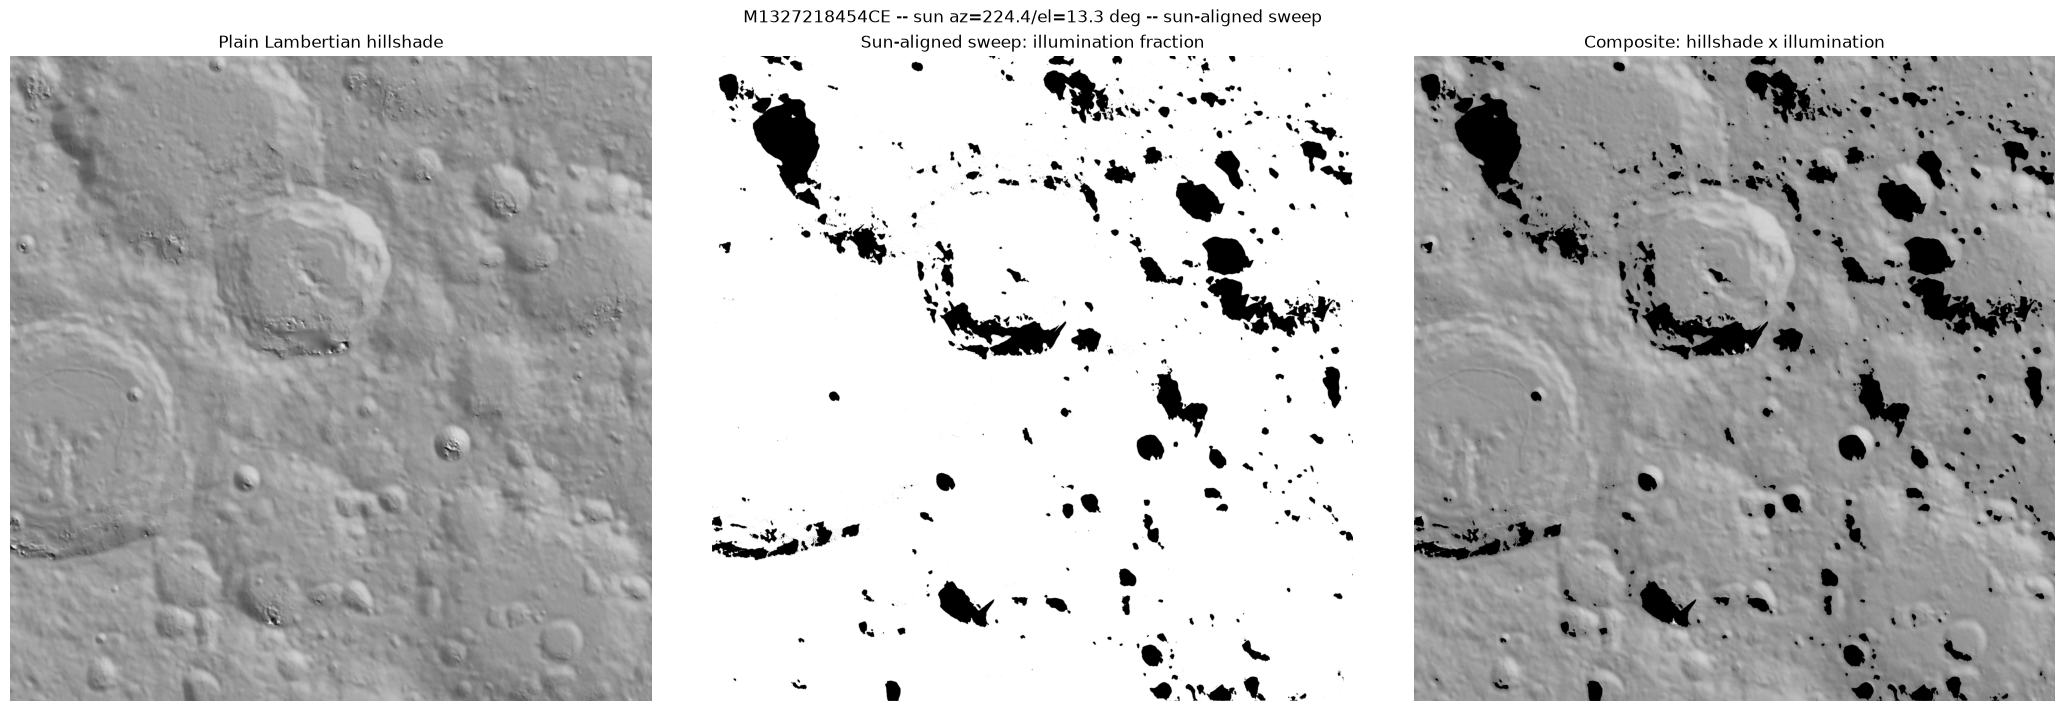

In [9]:
light = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg)
plain_hillshade = light.hillshade(dem, dx=cellsize_m, dy=cellsize_m)
composite = plain_hillshade * illumination_fraction

fig, axes = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=True)
axes[0].imshow(plain_hillshade, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Plain Lambertian hillshade")
axes[1].imshow(illumination_fraction, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Sun-aligned sweep: illumination fraction")
axes[2].imshow(composite, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Composite: hillshade x illumination")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"{entry.edr_product} -- sun az={azimuth_deg:.1f}/el={elevation_deg:.1f} deg -- sun-aligned sweep")
spike_dir = config.scratch_dir / "sun_aligned_shadow_sweep"
spike_dir.mkdir(parents=True, exist_ok=True)
png_path = spike_dir / f"{entry.edr_product}_sweep.png"
fig.savefig(png_path, dpi=150)
print(f"wrote {png_path}")

## Cross-tool pattern comparison against ISIS `shadow`

Not a correctness benchmark -- ISIS `shadow` isn't ground truth for either component (see the
markdown above), just a second implementation with its own approximations. This checks whether the
two agree on *where* shadow falls and on the row-1016/1023 pattern specifically, using
`illumination_fraction_for_isis_comparison` (self-shadow included, to match ISIS's own combined
semantics) -- not `illumination_fraction` itself, which is the tool's real output and deliberately
excludes self-shadow. Reuses `isis_shadow_spike.py`'s output from shared `scratch/` if present (same
DEM, same row indices) -- re-run that notebook first if it's been cleaned (unversioned scratch, see
`docs/environment.md`).

ISIS shadow mask illuminated fraction:      0.821
sweep illuminated fraction (incl. self-shadow): 0.914


wrote /workspace/scratch/sun_aligned_shadow_sweep/M1327218454CE_crop_comparison.png
crop illuminated fraction: ISIS=0.835, sweep=0.944
row 1016 (primary streak): ISIS shadow frac=0.364 (neighbors 0.352), sweep shadow frac=0.202 (neighbors 0.202)
row 1023 (caching artifact): ISIS shadow frac=0.298 (neighbors 0.283), sweep shadow frac=0.213 (neighbors 0.213)
wrote /workspace/scratch/sun_aligned_shadow_sweep/M1327218454CE_row_mean_shadow_comparison.png


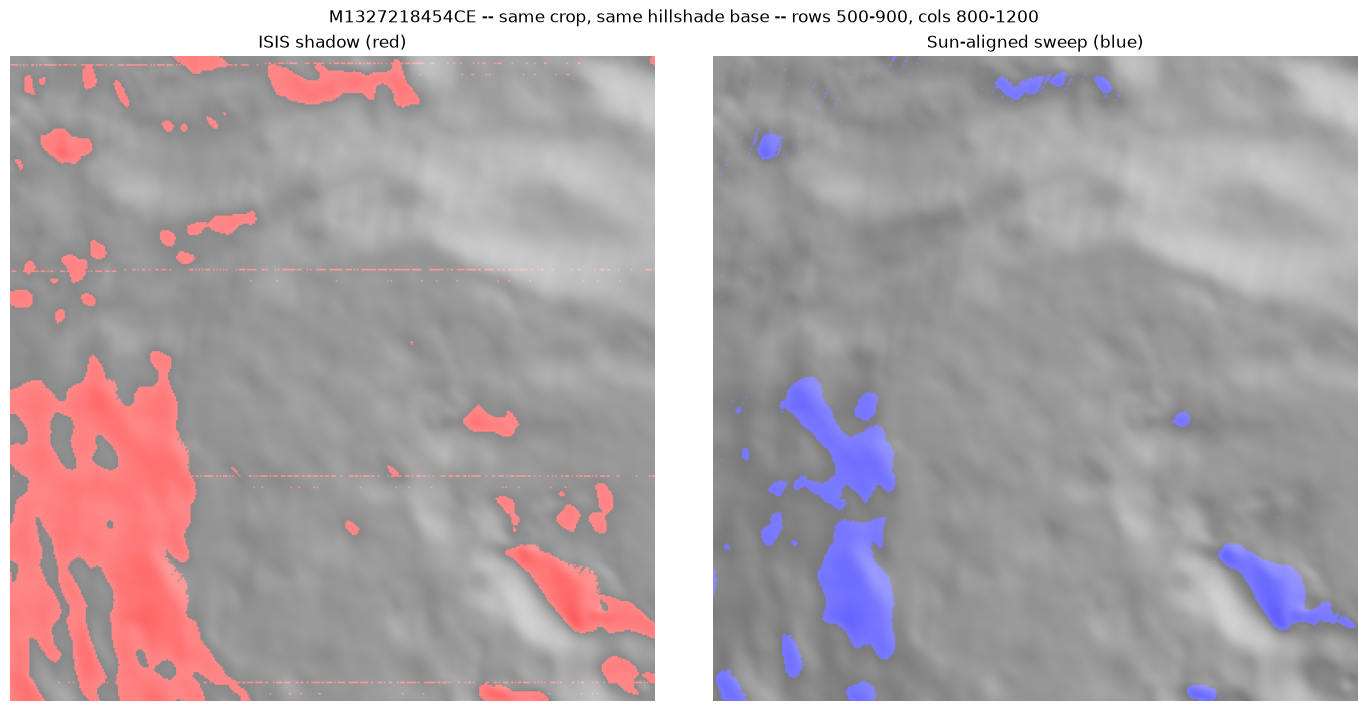

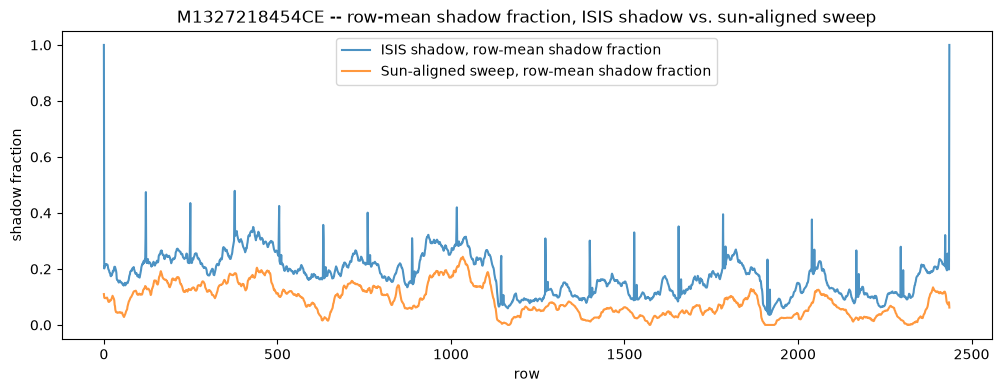

In [10]:
isis_shadow_tif = config.scratch_dir / "isis_shadow_spike" / f"{entry.edr_product}_dem_radius.shadow.tif"
if isis_shadow_tif.exists():
    with rasterio.open(isis_shadow_tif) as src:
        isis_shadow_val = src.read(1, masked=True)
    is_lit_isis = ~np.ma.getmaskarray(isis_shadow_val)
    sweep_illum = illumination_fraction_for_isis_comparison
    print(f"ISIS shadow mask illuminated fraction:      {is_lit_isis.mean():.3f}")
    print(f"sweep illuminated fraction (incl. self-shadow): {np.nanmean(sweep_illum):.3f}")

    # Is that gap a direction bug, or under-detection? A decisive check, not a guess: crop the same
    # region from both masks over the plain hillshade. Wrong-place patches (mirrored, rotated) would
    # be a real bug; right-place-but-smaller patches would be under-detection -- a real, different
    # problem, but not a broken frame/sweep direction.
    row_slice, col_slice = slice(500, 900), slice(800, 1200)
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
    sub_hillshade = plain_hillshade[row_slice, col_slice]
    isis_overlay = np.stack([sub_hillshade] * 3, axis=-1)
    isis_overlay[..., 0] = np.clip(isis_overlay[..., 0] + (~is_lit_isis)[row_slice, col_slice] * 0.6, 0, 1)
    axes[0].imshow(isis_overlay)
    axes[0].set_title("ISIS shadow (red)")
    sweep_overlay = np.stack([sub_hillshade] * 3, axis=-1)
    sweep_overlay[..., 2] = np.clip(
        sweep_overlay[..., 2] + np.nan_to_num(1.0 - sweep_illum[row_slice, col_slice]) * 0.7, 0, 1
    )
    axes[1].imshow(sweep_overlay)
    axes[1].set_title("Sun-aligned sweep (blue)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{entry.edr_product} -- same crop, same hillshade base -- rows 500-900, cols 800-1200")
    crop_png = spike_dir / f"{entry.edr_product}_crop_comparison.png"
    fig.savefig(crop_png, dpi=150)
    print(f"wrote {crop_png}")
    print(
        f"crop illuminated fraction: ISIS={is_lit_isis[row_slice, col_slice].mean():.3f}, "
        f"sweep={np.nanmean(sweep_illum[row_slice, col_slice]):.3f}"
    )
    # Finding: the two land in the same places (no direction/mirror bug), but the sweep marks
    # consistently less shadow -- a real discrepancy between the two implementations, not confirmed
    # to be caused by bin resolution (identical at UPSAMPLE_FACTOR=2 and 4) or the mean-vs-max binning
    # statistic. Not necessarily a flaw in the sweep specifically -- ISIS isn't ground truth either.

    rows_of_interest = {"row 1016 (primary streak)": 1016, "row 1023 (caching artifact)": 1023}
    for label, row in rows_of_interest.items():
        if row + 1 < height:
            isis_frac = 1.0 - is_lit_isis[row].mean()
            sweep_frac = 1.0 - np.nanmean(sweep_illum[row])
            neighbor_isis = 1.0 - np.mean([is_lit_isis[row - 1].mean(), is_lit_isis[row + 1].mean()])
            neighbor_sweep = 1.0 - np.nanmean([np.nanmean(sweep_illum[row - 1]), np.nanmean(sweep_illum[row + 1])])
            print(
                f"{label}: ISIS shadow frac={isis_frac:.3f} (neighbors {neighbor_isis:.3f}), "
                f"sweep shadow frac={sweep_frac:.3f} (neighbors {neighbor_sweep:.3f})"
            )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(1.0 - is_lit_isis.mean(axis=1), label="ISIS shadow, row-mean shadow fraction", alpha=0.8)
    ax.plot(1.0 - np.nanmean(sweep_illum, axis=1), label="Sun-aligned sweep, row-mean shadow fraction", alpha=0.8)
    ax.set_xlabel("row")
    ax.set_ylabel("shadow fraction")
    ax.legend()
    ax.set_title(f"{entry.edr_product} -- row-mean shadow fraction, ISIS shadow vs. sun-aligned sweep")
    row_compare_png = spike_dir / f"{entry.edr_product}_row_mean_shadow_comparison.png"
    fig.savefig(row_compare_png, dpi=150)
    print(f"wrote {row_compare_png}")
else:
    print(
        f"{isis_shadow_tif} not found -- run notebooks/isis_shadow_spike.py first to regenerate the "
        "ISIS shadow comparison output (shared, unversioned scratch/ dir)."
    )

## Ground truth check: real WAC imagery

ISIS `shadow` isn't ground truth (see above). Real calibrated WAC imagery is the closest thing this
project has to it -- the actual sensor observed real cast shadows on this candidate's real terrain,
unlike either shadow-mask tool's own model of it. `isis_wac.run_cam2map_for_crop` reprojects the
real WAC crop cube (`entry.crop_result`, already-cached, no network needed) onto a clone of
`dem_ortho_result`'s own CRS -- same projection as this notebook's DEM grid, but not the same pixel
grid/extent (`DEFAULTRANGE=camera` auto-sizes it to the crop's own footprint), so it still needs a
`rasterio.warp.reproject` onto our exact grid for a pixel-aligned comparison.

In [11]:
dem_ortho_result = dem_ortho.fetch_dem_and_ortho(camera, entry.config)
assert dem_ortho_result.dem == dem_result.dem, "expected dem_ortho_result to reuse the same fetch_dem output"

wac_cam2map_tif = isis_wac.run_cam2map_for_crop(entry.crop_result, dem_ortho_result, entry.config)
print(f"real WAC crop, reprojected onto this DEM's CRS: {wac_cam2map_tif}")

with rasterio.open(dem_result.dem) as dst_template:
    dst_transform, dst_crs, dst_shape = dst_template.transform, dst_template.crs, dst_template.shape

with rasterio.open(wac_cam2map_tif) as src:
    wac_src = src.read(1, masked=True).filled(np.nan).astype(np.float32)
    wac_on_dem_grid = np.full(dst_shape, np.nan, dtype=np.float32)
    rasterio.warp.reproject(
        source=wac_src,
        destination=wac_on_dem_grid,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=rasterio.warp.Resampling.bilinear,
    )
wac_valid = ~np.isnan(wac_on_dem_grid)
print(f"real WAC coverage of this DEM's grid: {wac_valid.mean():.3f}")
print(f"row 1016 coverage: {wac_valid[1016].mean():.3f}, cols 1400-1750: {wac_valid[1016, 1400:1750].mean():.3f}")

ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


WAC_EMP tile(s): WAC_EMP_643NM_P900N0000_304P


real WAC crop, reprojected onto this DEM's CRS: /workspace/output/crop/M1327218454CE_crop-cam2map.tif
real WAC coverage of this DEM's grid: 0.397
row 1016 coverage: 0.649, cols 1400-1750: 1.000


## The actual row-1016 question, against real data

`gld100_banding_investigation.py` never got to this check -- comparing against synthetic shading
only, not a real WAC crop. This is the first time this specific streak has been checked against
what the sensor actually saw.

wrote /workspace/scratch/sun_aligned_shadow_sweep/M1327218454CE_row1016_vs_real_wac.png
row 1016 real WAC brightness: mean=0.0153, neighbors mean=0.0153


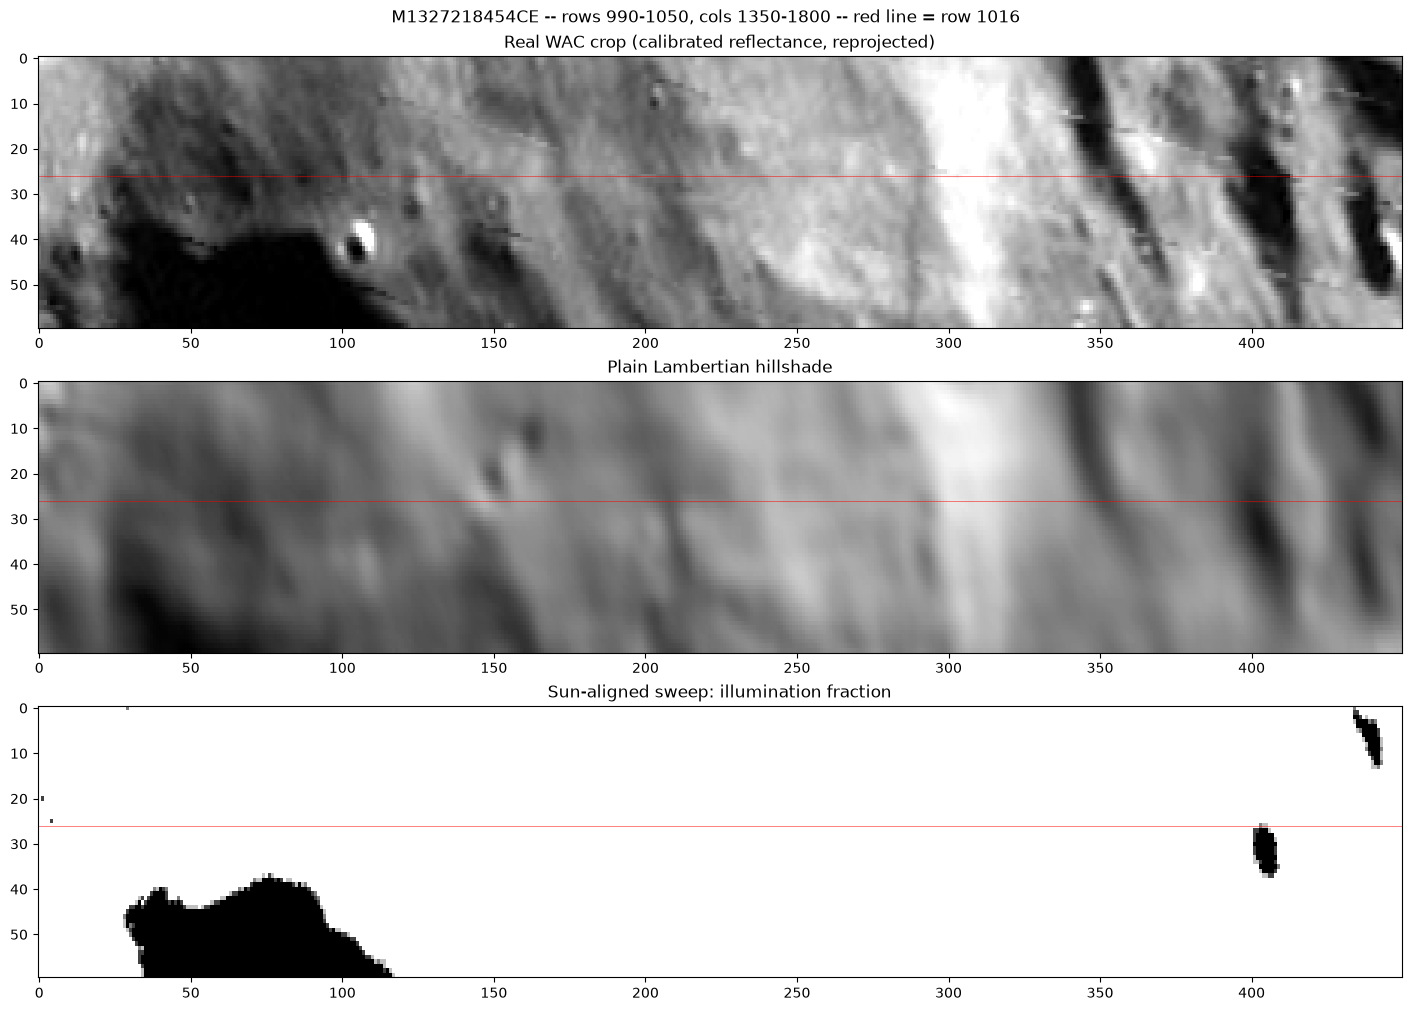

In [12]:
row_lo, row_hi, col_lo, col_hi = 990, 1050, 1350, 1800
wac_strip = wac_on_dem_grid[row_lo:row_hi, col_lo:col_hi]
fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)
valid_wac_strip = wac_strip[np.isfinite(wac_strip)]
vmin, vmax = np.percentile(valid_wac_strip, [2, 98]) if valid_wac_strip.size else (0, 1)
axes[0].imshow(wac_strip, cmap="gray", vmin=vmin, vmax=vmax, aspect="auto", interpolation="none")
axes[0].set_title("Real WAC crop (calibrated reflectance, reprojected)")
axes[1].imshow(plain_hillshade[row_lo:row_hi, col_lo:col_hi], cmap="gray", aspect="auto", interpolation="none")
axes[1].set_title("Plain Lambertian hillshade")
axes[2].imshow(
    illumination_fraction[row_lo:row_hi, col_lo:col_hi],
    cmap="gray",
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="none",
)
axes[2].set_title("Sun-aligned sweep: illumination fraction")
for ax in axes:
    ax.axhline(1016 - row_lo, color="red", lw=0.5, alpha=0.7)
fig.suptitle(f"{entry.edr_product} -- rows {row_lo}-{row_hi}, cols {col_lo}-{col_hi} -- red line = row 1016")
row1016_png = spike_dir / f"{entry.edr_product}_row1016_vs_real_wac.png"
fig.savefig(row1016_png, dpi=150)
print(f"wrote {row1016_png}")

wac_row1016 = wac_on_dem_grid[1016, col_lo:col_hi]
wac_neighbors = np.nanmean([wac_on_dem_grid[1015, col_lo:col_hi], wac_on_dem_grid[1017, col_lo:col_hi]], axis=0)
print(
    f"row 1016 real WAC brightness: mean={np.nanmean(wac_row1016):.4f}, neighbors mean={np.nanmean(wac_neighbors):.4f}"
)

## Broader check: does illumination_fraction track real brightness at all?

Not a strict validation (real brightness also depends on albedo, which the sweep knows nothing
about) but a sanity floor: real shadowed regions should read darker on average than real lit
regions, if either tool's shadow determination means anything here.

In [13]:
valid_both = wac_valid & np.isfinite(illumination_fraction)
lit_mask = valid_both & (illumination_fraction > CONFIDENT_LIT_THRESHOLD)
shadow_mask = valid_both & (illumination_fraction < CONFIDENT_SHADOW_THRESHOLD)
print(
    f"real WAC brightness where sweep says lit (>0.9):     mean={wac_on_dem_grid[lit_mask].mean():.4f}, n={lit_mask.sum()}"
)
print(
    f"real WAC brightness where sweep says shadowed (<0.1): mean={wac_on_dem_grid[shadow_mask].mean():.4f}, n={shadow_mask.sum()}"
)

if isis_shadow_tif.exists():
    isis_lit_mask = valid_both & is_lit_isis
    isis_shadow_mask = valid_both & ~is_lit_isis
    print(
        f"real WAC brightness where ISIS says lit:      mean={wac_on_dem_grid[isis_lit_mask].mean():.4f}, "
        f"n={isis_lit_mask.sum()}"
    )
    print(
        f"real WAC brightness where ISIS says shadowed: mean={wac_on_dem_grid[isis_shadow_mask].mean():.4f}, "
        f"n={isis_shadow_mask.sum()}"
    )

real WAC brightness where sweep says lit (>0.9):     mean=0.0174, n=2148936
real WAC brightness where sweep says shadowed (<0.1): mean=0.0023, n=179917
real WAC brightness where ISIS says lit:      mean=0.0184, n=1952717
real WAC brightness where ISIS says shadowed: mean=0.0047, n=392419
